In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [16]:
df = pd.read_csv('../data/car data.csv')

print("Shape:", df.shape)
print("\nAll columns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (14993, 11)

All columns:
['Brand', 'model', 'Year', 'Age', 'kmDriven', 'Transmission', 'Owner', 'FuelType', 'PostedDate', 'AdditionInfo', 'AskPrice']

First 5 rows:


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


In [17]:
print("Shape:", df.shape)
print("\nAll columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Shape: (14993, 11)

All columns: ['Brand', 'model', 'Year', 'Age', 'kmDriven', 'Transmission', 'Owner', 'FuelType', 'PostedDate', 'AdditionInfo', 'AskPrice']

Missing values:
Brand            0
model            0
Year             0
Age              0
kmDriven        88
Transmission     0
Owner            0
FuelType         0
PostedDate       0
AdditionInfo     0
AskPrice         0
dtype: int64

Data types:
Brand             str
model             str
Year            int64
Age             int64
kmDriven          str
Transmission      str
Owner             str
FuelType          str
PostedDate        str
AdditionInfo      str
AskPrice          str
dtype: object


In [18]:
# Clean kmDriven (remove 'km' and commas)
df['kmDriven'] = df['kmDriven'].astype(str).str.replace('km', '').str.replace(',', '').str.strip()
df['kmDriven'] = pd.to_numeric(df['kmDriven'], errors='coerce')

# Clean AskPrice (remove currency symbols and commas)
df['AskPrice'] = df['AskPrice'].astype(str).str.replace('₹', '').str.replace(',', '').str.strip()
df['AskPrice'] = pd.to_numeric(df['AskPrice'], errors='coerce')

# Fill missing kmDriven with median
df['kmDriven'].fillna(df['kmDriven'].median(), inplace=True)

# Drop rows where AskPrice is missing
df.dropna(subset=['AskPrice'], inplace=True)

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Brand'] = le.fit_transform(df['Brand'])
df['model'] = le.fit_transform(df['model'])
df['Transmission'] = le.fit_transform(df['Transmission'])
df['Owner'] = le.fit_transform(df['Owner'])
df['FuelType'] = le.fit_transform(df['FuelType'])

print("Clean shape:", df.shape)
print("\nData types now:")
print(df.dtypes)
df.head()

Clean shape: (14993, 11)

Data types now:
Brand             int64
model             int64
Year              int64
Age               int64
kmDriven        float64
Transmission      int64
Owner             int64
FuelType          int64
PostedDate          str
AdditionInfo        str
AskPrice          int64
dtype: object


/var/folders/cf/mjvhpkbn4t315lx_dg80zx440000gn/T/ipykernel_23480/1811660653.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['kmDriven'].fillna(df['kmDriven'].median(), inplace=True)


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,13,88,2001,23,98000.0,1,1,2,Nov-24,"Honda City v teck in mint condition, valid gen...",195000
1,39,199,2009,15,190000.0,1,1,0,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...",375000
2,41,377,2010,14,77246.0,1,0,0,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...",184999
3,26,344,2017,7,83500.0,1,1,0,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,565000
4,26,55,2019,5,45000.0,0,0,2,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",685000


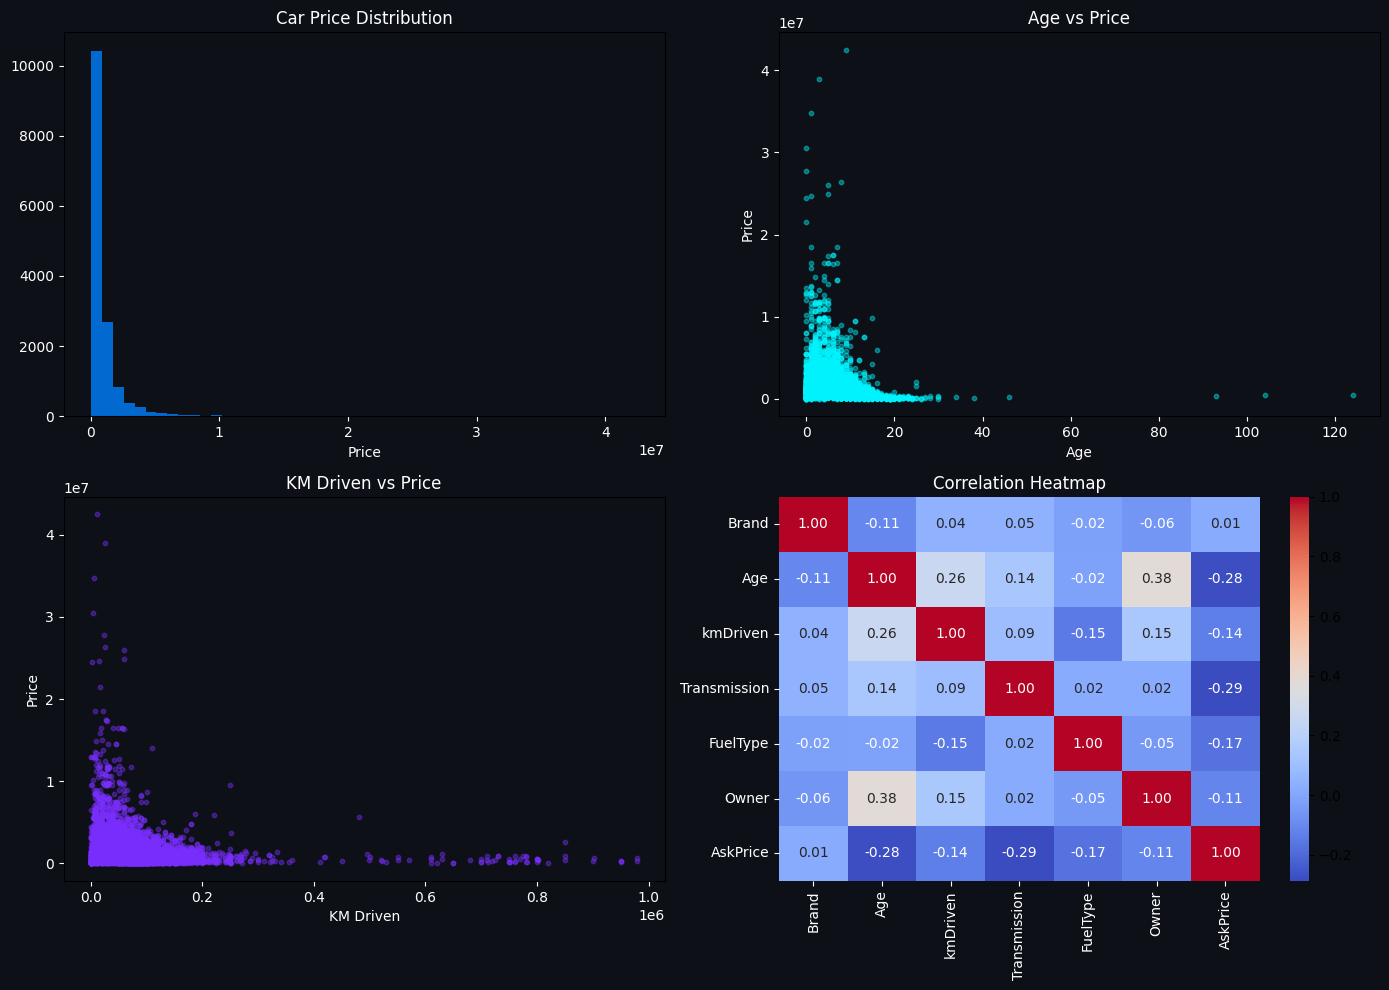

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0d1117')

# Chart 1 - Price distribution
axes[0,0].set_facecolor('#0d1117')
axes[0,0].hist(df['AskPrice'], bins=50, color='#0080ff', alpha=0.8)
axes[0,0].set_title('Car Price Distribution', color='white')
axes[0,0].tick_params(colors='white')
axes[0,0].set_xlabel('Price', color='white')

# Chart 2 - Age vs Price
axes[0,1].set_facecolor('#0d1117')
axes[0,1].scatter(df['Age'], df['AskPrice'], color='#00f5ff', alpha=0.4, s=10)
axes[0,1].set_title('Age vs Price', color='white')
axes[0,1].tick_params(colors='white')
axes[0,1].set_xlabel('Age', color='white')
axes[0,1].set_ylabel('Price', color='white')

# Chart 3 - kmDriven vs Price
axes[1,0].set_facecolor('#0d1117')
axes[1,0].scatter(df['kmDriven'], df['AskPrice'], color='#7b2fff', alpha=0.4, s=10)
axes[1,0].set_title('KM Driven vs Price', color='white')
axes[1,0].tick_params(colors='white')
axes[1,0].set_xlabel('KM Driven', color='white')
axes[1,0].set_ylabel('Price', color='white')

# Chart 4 - Correlation heatmap
axes[1,1].set_facecolor('#0d1117')
numeric_cols = ['Brand', 'Age', 'kmDriven', 'Transmission', 'FuelType', 'Owner', 'AskPrice']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap', color='white')
axes[1,1].tick_params(colors='white')

plt.tight_layout()
plt.show()

In [21]:
# Drop all remaining NaN values
df.dropna(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print("Clean shape:", df.shape)
print("Any NaN left:", df.isnull().sum().sum())

Clean shape: (14905, 11)
Any NaN left: 0


In [22]:
# Features and target
features = ['Brand', 'model', 'Age', 'kmDriven', 'Transmission', 'Owner', 'FuelType']
X = df[features]
y = df['AskPrice']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("\nLinear Regression Results:")
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, lr_pred)), 2))
print("MAE:", round(mean_absolute_error(y_test, lr_pred), 2))
print("R2 Score:", round(r2_score(y_test, lr_pred), 2))

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\nRandom Forest Results:")
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, rf_pred)), 2))
print("MAE:", round(mean_absolute_error(y_test, rf_pred), 2))
print("R2 Score:", round(r2_score(y_test, rf_pred), 2))

Training size: (11924, 7)
Testing size: (2981, 7)

Linear Regression Results:
RMSE: 1478839.49
MAE: 669851.23
R2 Score: 0.15

Random Forest Results:
RMSE: 814365.9
MAE: 216021.76
R2 Score: 0.74


In [23]:
import joblib

joblib.dump(rf, '../models/car_price_model.pkl')
print("Model saved!")

# Test it
test_input = [[13, 88, 23, 98000, 1, 1, 2]]
prediction = joblib.load('../models/car_price_model.pkl').predict(test_input)
print("Test prediction: ₹", round(prediction[0], 2))

Model saved!
Test prediction: ₹ 179778.33


/Users/aaravbhasin/car-price-prediction/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
